# Latent SOH Walkthrough

This notebook explains the condition-aware latent SOH target used in `ml_workspace/latent_soh`.

The main idea is simple:
- treat the BMS SOH estimate as a noisy observation, not ground truth
- trust that observation less when the estimator is likely stressed
- smooth the event-level SOH sequence with a random-walk state-space model
- keep the residuals as useful diagnostics instead of training directly on spikes


In [1]:
from pathlib import Path
import sys

import json
import matplotlib.pyplot as plt
import pandas as pd

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / ".gitignore").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing ml_workspace")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.latent_soh.build_latent_soh import build_latent_soh_labels

PLANE_ID = "166"
RUN_PIPELINE = False
COMPARE_BACKEND = True
RT_PROFILE = "balanced"
Q_DAY_SIGMA_PCT = 0.05

OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "latent_soh" / "output" / f"plane_{PLANE_ID}"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
if RUN_PIPELINE:
    result = build_latent_soh_labels(
        plane_id=PLANE_ID,
        timeseries_path="data/event_timeseries.parquet",
        spec_path="ml_workspace/battery_specs.yaml",
        output_dir=OUTPUT_DIR,
        q_day_sigma_pct=Q_DAY_SIGMA_PCT,
        rt_profile=RT_PROFILE,
        compare_backend=COMPARE_BACKEND,
    )
    print(json.dumps(result, indent=2))
else:
    print(f"Using existing outputs in {OUTPUT_DIR}")


Using existing outputs in /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/latent_soh/output/plane_166


In [3]:
event_df = pd.read_csv(OUTPUT_DIR / "event_observation_table.csv", parse_dates=["event_datetime"])
latent_df = pd.read_csv(OUTPUT_DIR / "latent_soh_event_table.csv", parse_dates=["event_datetime"])
summary = json.loads((OUTPUT_DIR / "diagnostics" / "smoother_summary.json").read_text())
backend_summary = json.loads((OUTPUT_DIR / "diagnostics" / "backend_agreement_summary.json").read_text())
top_spikes = pd.read_csv(OUTPUT_DIR / "diagnostics" / "top_raw_spike_events.csv", parse_dates=["event_datetime"])
spike_summary = pd.read_csv(OUTPUT_DIR / "diagnostics" / "spike_feature_summary.csv")

print(f"Event observations: {len(event_df):,}")
print(f"Latent rows: {len(latent_df):,}")
pd.DataFrame(backend_summary)


Event observations: 1,106
Latent rows: 1,106


,plane_id,battery_id,compare_backend_enabled,n_events_compared,median_abs_backend_delta_pct,p95_abs_backend_delta_pct,max_abs_backend_delta_pct
0,166,1,True,553,0.0,2.984279e-13,5.542233e-13
1,166,2,True,553,0.0,8.526513e-14,1.705303e-13


## 1. Raw observed SOH over time

This is the label we do **not** want to trust directly. The large upward steps are the core motivation for the latent target.

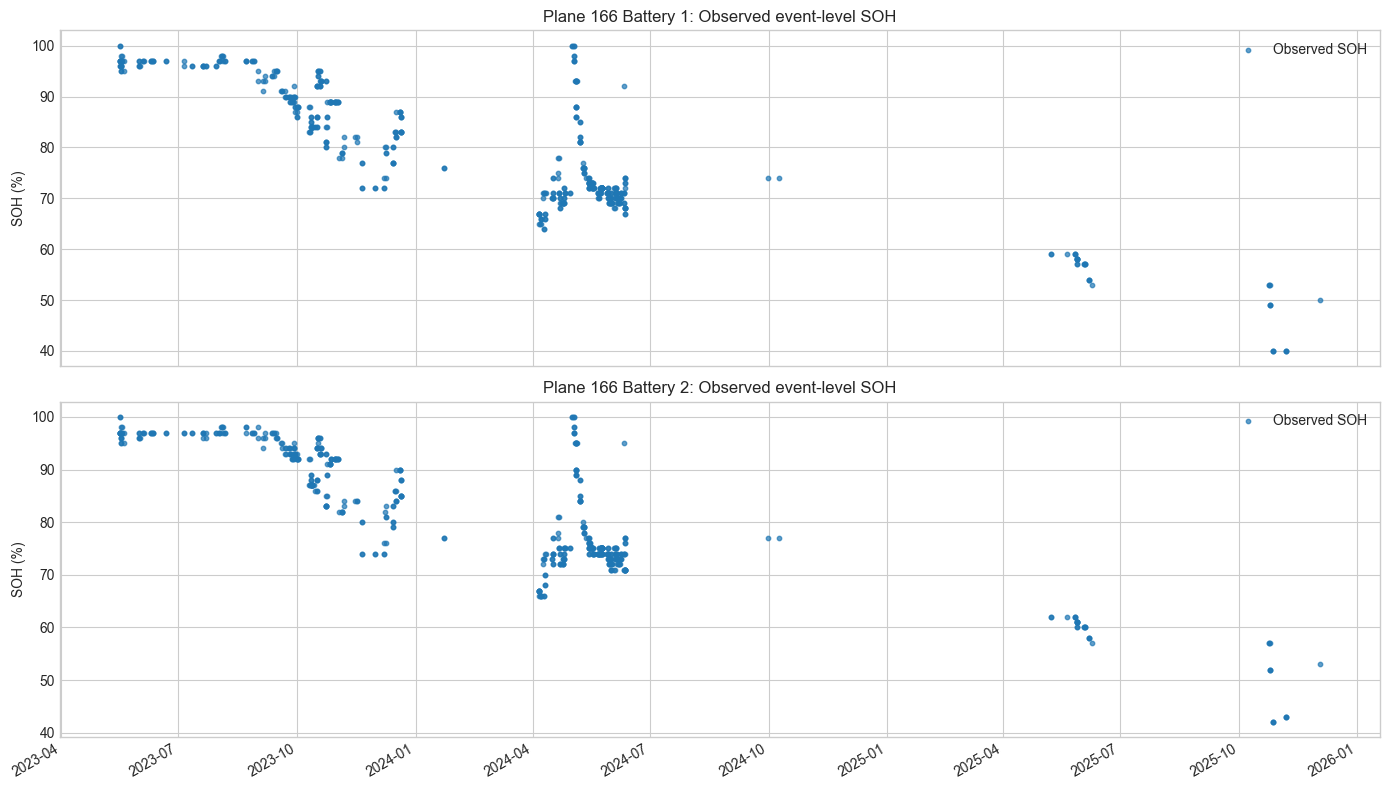

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (battery_id, group) in zip(axes, latent_df.groupby("battery_id", sort=True)):
    g = group.sort_values(["event_datetime", "flight_id"])
    ax.scatter(g["event_datetime"], g["observed_soh_pct"], s=10, alpha=0.7, label="Observed SOH")
    ax.set_title(f"Plane {PLANE_ID} Battery {battery_id}: Observed event-level SOH")
    ax.set_ylabel("SOH (%)")
    ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()


## 2. Condition scores and time-varying trust

`R_t` is larger when the estimator is under worse conditions. That downweights current spikes, dynamic charge segments, SOC edge behavior, and estimator resets.

In [5]:
condition_cols = [
    "score_current",
    "score_didt",
    "score_dtemp",
    "score_soc_edge",
    "score_gap",
    "score_switch",
    "score_event_type",
    "condition_multiplier",
    "measurement_sigma_pct",
]
latent_df.groupby("battery_id")[condition_cols].median().round(3)


,score_current,score_didt,score_dtemp,score_soc_edge,score_gap,score_switch,score_event_type,condition_multiplier,measurement_sigma_pct
battery_id,,,,,,,,,
1,0.595,0.301,0.0,1.0,1.530,0.5,0.75,2.638,1.451
2,0.582,0.300,0.0,1.0,1.527,0.5,0.75,2.598,1.429


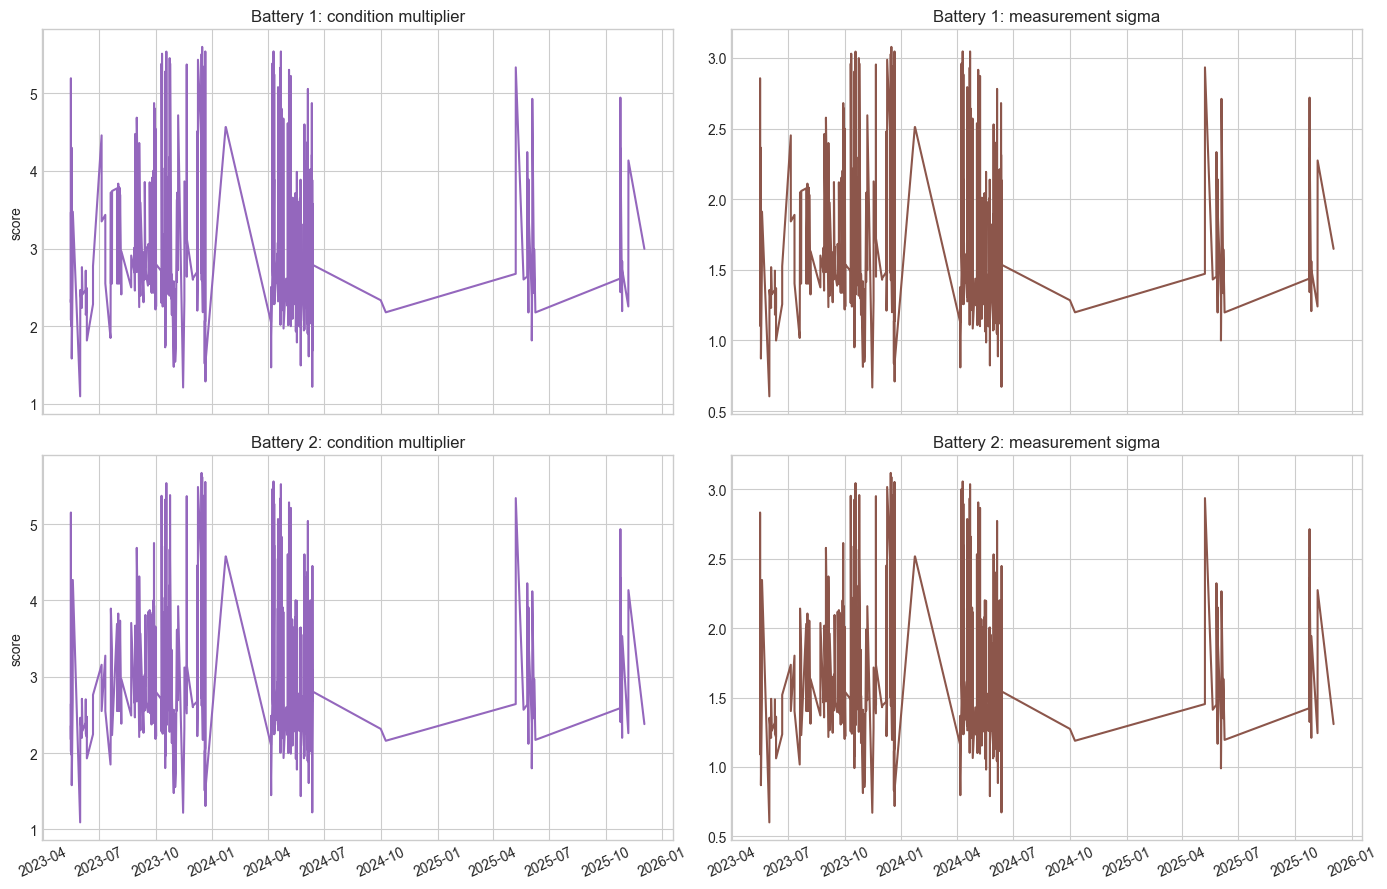

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')
for row_idx, (battery_id, group) in enumerate(latent_df.groupby("battery_id", sort=True)):
    g = group.sort_values(["event_datetime", "flight_id"])
    axes[row_idx, 0].plot(g["event_datetime"], g["condition_multiplier"], color="#9467bd")
    axes[row_idx, 0].set_title(f"Battery {battery_id}: condition multiplier")
    axes[row_idx, 1].plot(g["event_datetime"], g["measurement_sigma_pct"], color="#8c564b")
    axes[row_idx, 1].set_title(f"Battery {battery_id}: measurement sigma")
    axes[row_idx, 0].set_ylabel("score")
for ax in axes.ravel():
    ax.tick_params(axis='x', rotation=25)
fig.tight_layout()


## 3. Filtered vs smoothed latent SOH

FilterPy is the canonical backend. The RTS smoother uses the whole sequence, so it is the main offline training label.

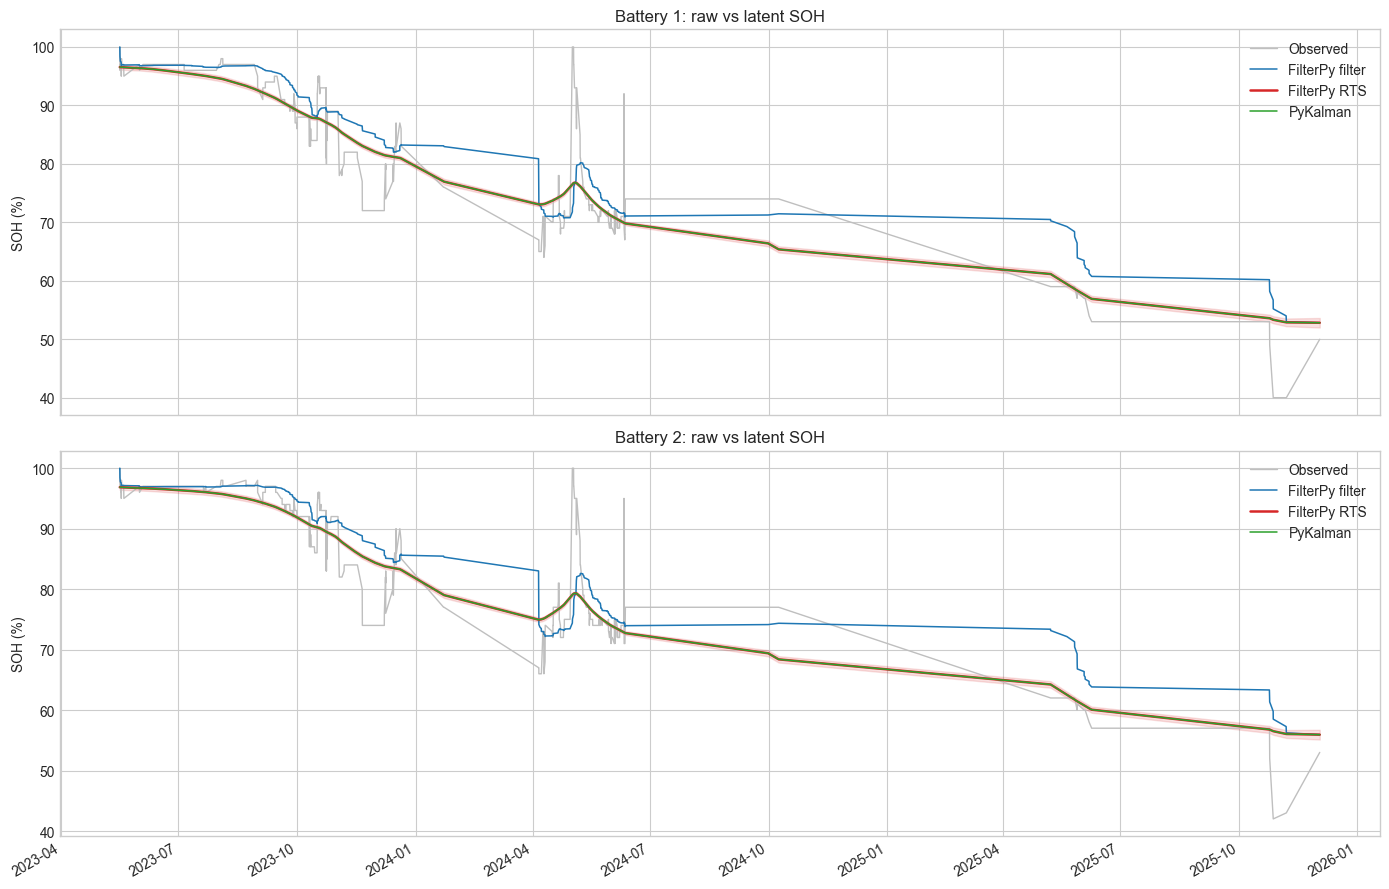

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, (battery_id, group) in zip(axes, latent_df.groupby("battery_id", sort=True)):
    g = group.sort_values(["event_datetime", "flight_id"])
    ax.plot(g["event_datetime"], g["observed_soh_pct"], color="0.75", linewidth=1.0, label="Observed")
    ax.plot(g["event_datetime"], g["latent_soh_filter_pct"], color="#1f77b4", linewidth=1.1, label="FilterPy filter")
    ax.plot(g["event_datetime"], g["latent_soh_smooth_pct"], color="#d62728", linewidth=1.8, label="FilterPy RTS")
    if g["latent_soh_pykalman_smooth_pct"].notna().any():
        ax.plot(g["event_datetime"], g["latent_soh_pykalman_smooth_pct"], color="#2ca02c", linewidth=1.1, label="PyKalman")
    band_low = g["latent_soh_smooth_pct"] - 2.0 * g["latent_soh_smooth_std_pct"]
    band_high = g["latent_soh_smooth_pct"] + 2.0 * g["latent_soh_smooth_std_pct"]
    ax.fill_between(g["event_datetime"], band_low, band_high, color="#d62728", alpha=0.14)
    ax.set_title(f"Battery {battery_id}: raw vs latent SOH")
    ax.set_ylabel("SOH (%)")
    ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()


## 4. Residual diagnostics

Residuals tell us where the BMS estimate disagrees with the latent state. These are useful diagnostics and later can become downstream features.

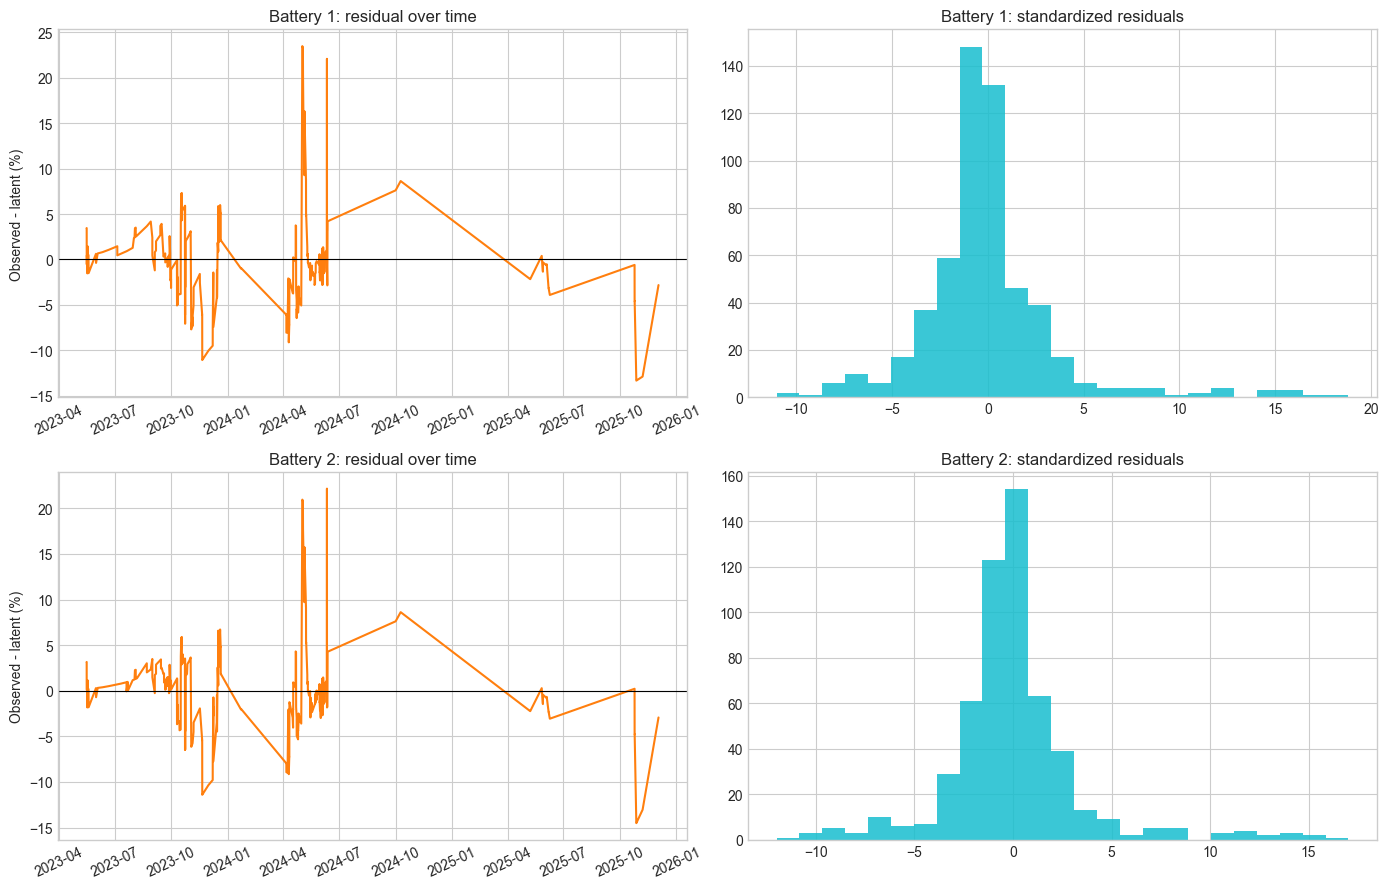

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row_idx, (battery_id, group) in enumerate(latent_df.groupby("battery_id", sort=True)):
    g = group.sort_values(["event_datetime", "flight_id"])
    axes[row_idx, 0].plot(g["event_datetime"], g["residual_pct"], color="#ff7f0e")
    axes[row_idx, 0].axhline(0.0, color="black", linewidth=0.8)
    axes[row_idx, 0].set_title(f"Battery {battery_id}: residual over time")
    axes[row_idx, 0].set_ylabel("Observed - latent (%)")
    axes[row_idx, 1].hist(g["standardized_residual"].dropna(), bins=25, color="#17becf", alpha=0.85)
    axes[row_idx, 1].set_title(f"Battery {battery_id}: standardized residuals")
for ax in axes[:, 0]:
    ax.tick_params(axis='x', rotation=25)
fig.tight_layout()


## 5. How much spike suppression did we get?

This compares the worst raw upward event jump against the worst upward jump after smoothing.

In [9]:
summary_table = pd.DataFrame({
    'battery_id': [int(k) for k in summary['raw_max_upward_jump_pct_per_battery'].keys()],
    'raw_max_upward_jump_pct': list(summary['raw_max_upward_jump_pct_per_battery'].values()),
    'smoothed_max_upward_jump_pct': list(summary['smoothed_max_upward_jump_pct_per_battery'].values()),
    'raw_total_variation_pct': list(summary['raw_total_variation_per_battery'].values()),
    'smoothed_total_variation_pct': list(summary['smoothed_total_variation_per_battery'].values()),
})
summary_table['jump_reduction_pct'] = 100.0 * (1.0 - (summary_table['smoothed_max_upward_jump_pct'].clip(lower=0.0) / summary_table['raw_max_upward_jump_pct'].replace(0, pd.NA)))
summary_table.round(4)


,battery_id,raw_max_upward_jump_pct,smoothed_max_upward_jump_pct,raw_total_variation_pct,smoothed_total_variation_pct,jump_reduction_pct
0,1,29.0,1.0244,484.0,51.1472,96.4676
1,2,25.0,1.0230,469.0,49.6943,95.9082


## 6. Exported files

The latent outputs are joinable later on:
- `plane_id`
- `battery_id`
- `flight_id`
- `event_datetime`

Most important downstream columns:
- `latent_soh_smooth_pct`
- `latent_soh_smooth_std_pct`
- `latent_soh_monotone_pct`
- `residual_pct`
- rolling residual features


## 7. What appears to cause the biggest spikes?

The tables below are the first place to look. They show the largest raw upward jumps together with the switch flags, gap score, instability score, event type, and measurement sigma used by the smoother.

In [10]:
top_spikes.groupby("battery_id").head(10)


,plane_id,battery_id,flight_id,event_datetime,event_type,delta_observed_soh_pct,delta_latent_soh_pct,observed_soh_pct,latent_soh_smooth_pct,residual_pct,...,condition_multiplier,measurement_sigma_pct,flag_new_est_batt_cap_any,flag_rst_coulomb_any,kalman_coulomb_gap_mean_pct,kalman_coulomb_gap_span_pct,p95_abs_current_a,p95_abs_dcurrent_a_per_s,soc_min_pct,soc_max_pct
0,166,1,5899,2024-05-01 17:00:00,charge,29.0,0.461612,100.0,76.529164,23.470836,...,2.266840,1.246762,0,0,1.421857,3.37,24.0,0.999393,81.0,99.0
1,166,1,6363,2024-06-10 19:00:00,charge,21.0,-0.016750,92.0,69.925621,22.074379,...,4.872997,2.680149,1,1,-1.794709,3.03,24.6,0.500495,0.0,100.0
2,166,1,5036,2023-10-23 17:00:00,charge,12.0,-0.002659,93.0,87.090351,5.909649,...,2.394892,1.317190,1,1,-0.605124,1.26,5.3,0.500718,29.0,61.0
3,166,1,12722,2025-12-02 17:35:00,charge,10.0,-0.067242,50.0,52.818784,-2.818784,...,2.996664,1.648165,1,1,-0.108456,7.75,3.7,1.990126,44.0,100.0
4,166,1,5921,2024-05-05 02:50:00,charge,7.0,-0.033536,93.0,76.686127,16.313873,...,2.454880,1.350184,0,1,0.250770,3.11,25.6,0.500714,64.0,100.0
5,166,1,5004,2023-10-16 16:30:00,charge,6.0,-0.000104,92.0,87.794790,4.205210,...,1.750298,0.962664,0,0,2.141706,1.39,9.6,0.500278,91.0,96.0
6,166,1,5298,2023-12-08 16:44:00,other,6.0,-0.045418,80.0,81.441016,-1.441016,...,2.693652,1.481509,0,1,-1.378468,4.11,72.6,4.477785,28.0,99.0
7,166,1,5363,2023-12-15 17:05:00,charge,6.0,-0.021280,83.0,81.156766,1.843234,...,5.596491,3.078070,1,1,3.869406,3.09,24.6,0.500636,28.0,96.0
8,166,1,4974,2023-10-10 17:54:00,charge,5.0,-0.001157,88.0,88.051833,-0.051833,...,5.380830,2.959457,1,1,0.641858,3.76,12.4,0.500540,36.0,98.0
9,166,1,5368,2023-12-16 21:15:00,charge,5.0,-0.001423,87.0,81.123122,5.876878,...,5.342852,2.938569,1,1,0.221466,2.65,22.3,0.500490,28.0,100.0


In [11]:
spike_summary.round(3)


,plane_id,battery_id,group_type,n_events,charge_fraction,flight_fraction,other_fraction,new_est_flag_fraction,rst_coulomb_flag_fraction,score_current_mean,...,measurement_sigma_pct_mean,measurement_sigma_pct_median,p95_abs_current_a_mean,p95_abs_current_a_median,p95_abs_dcurrent_a_per_s_mean,p95_abs_dcurrent_a_per_s_median,kalman_coulomb_gap_mean_pct_mean,kalman_coulomb_gap_mean_pct_median,kalman_coulomb_gap_span_pct_mean,kalman_coulomb_gap_span_pct_median
0,166,1,spike,35,0.714,0.086,0.200,0.571,0.857,0.521,...,2.034,2.101,32.405,24.6,2.012,0.501,-0.353,-0.258,2.611,2.840
1,166,1,non_spike,518,0.537,0.359,0.104,0.340,0.896,0.551,...,1.555,1.443,41.967,26.8,9.412,1.989,0.228,-0.810,11.289,2.725
2,166,2,spike,37,0.730,0.081,0.189,0.568,0.865,0.521,...,2.006,2.163,31.477,24.5,1.816,0.501,-0.383,-0.602,2.600,2.870
3,166,2,non_spike,516,0.535,0.360,0.105,0.328,0.899,0.533,...,1.528,1.427,40.590,25.8,6.932,1.838,-0.066,-0.769,9.426,2.730
